In [23]:
import pandas as pd

In [24]:
df = pd.read_csv('data.csv')

In [25]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [27]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


### Pré-processamento de dados

Começarei limpando o conjunto de dados:
1. ** Foi Removida colunas irrelevantes**: A coluna 'id' é apenas um identificador e 'Sem nome: 32' contém apenas valores nulos.

2. **Codificar a variável alvo**: A coluna 'diagnosis', que indica 'Maligno' ou 'Benigno', foi convertida para formato numérico (por exemplo, M=1, B=0).

In [28]:
# Drop 'id' and 'Unnamed: 32' columns
df_processed = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# Encode the 'diagnosis' column (M=1, B=0)
df_processed['diagnosis'] = df_processed['diagnosis'].map({'M': 1, 'B': 0})

display(df_processed.head())

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Separação de Características e Alvo

Agora, vou separar o conjunto de dados em características (X) e a variável alvo (y).

In [29]:
# Separate features (X) and target (y)
X = df_processed.drop('diagnosis', axis=1)
y = df_processed['diagnosis']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (569, 30)
Shape of target (y): (569,)


### Divisão em Conjuntos de Treinamento e Teste

Por fim, dividirei os dados pré-processados em conjuntos de treinamento e teste para avaliar o desempenho do modelo em dados não vistos. Utilizarei a função train_test_split com um test_size de 0.2 (20% para o conjunto de teste) e random_state=42 para garantir a reprodutibilidade dos resultados. Após a divisão, os dados de treino e teste serão armazenados nas variáveis X_train_actual, X_test_actual, y_train_actual e y_test_actual, permitindo validar as dimensões (shape) de cada matriz antes de iniciar a modelagem.

In [30]:
from sklearn.model_selection import train_test_split

X_train_actual, X_test_actual, y_train_actual, y_test_actual = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train_actual: {X_train_actual.shape}")
print(f"Shape of X_test_actual: {X_test_actual.shape}")
print(f"Shape of y_train_actual: {y_train_actual.shape}")
print(f"Shape of y_test_actual: {y_test_actual.shape}")

Shape of X_train_actual: (455, 30)
Shape of X_test_actual: (114, 30)
Shape of y_train_actual: (455,)
Shape of y_test_actual: (114,)


### Retreinar os modelos com dados reais

Agora vou retreinar os modelos `DecisionTreeClassifier` e `LogisticRegression` usando os dados de treinamento pré-processados ​​reais (`X_train_actual`, `y_train_actual`).

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Instantiate the Decision Tree Classifier (if not already defined or if kernel state was reset)
dt = DecisionTreeClassifier(max_depth=6, random_state=42)

# Instantiate the Logistic Regression model (if not already defined or if kernel state was reset)
logreg = LogisticRegression(random_state=1)

# Retrain Decision Tree Classifier on actual data
dt.fit(X_train_actual, y_train_actual)

# Retrain Logistic Regression on actual data
logreg.fit(X_train_actual, y_train_actual)

print("Models retrained successfully on actual data.")

Models retrained successfully on actual data.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Avaliar a Precisão do Modelo

Agora, vamos avaliar a precisão de ambos os modelos no conjunto de teste real (`X_test_actual`, `y_test_actual`).

In [32]:
from sklearn.metrics import accuracy_score

# Predict on the test set for Decision Tree
y_pred_dt = dt.predict(X_test_actual)
acc_dt = accuracy_score(y_test_actual, y_pred_dt)
print(f"Decision Tree Test set accuracy: {acc_dt:.4f}")

# Predict on the test set for Logistic Regression
y_pred_logreg = logreg.predict(X_test_actual)
acc_logreg = accuracy_score(y_test_actual, y_pred_logreg)
print(f"Logistic Regression Test set accuracy: {acc_logreg:.4f}")

Decision Tree Test set accuracy: 0.9386
Logistic Regression Test set accuracy: 0.9561


### Comparação visual das previsões

Agora, vamos criar uma comparação visual das previsões de ambos os modelos com os rótulos reais no conjunto de teste. Isso permitirá uma inspeção direta de quão bem cada modelo classificou as amostras individuais.

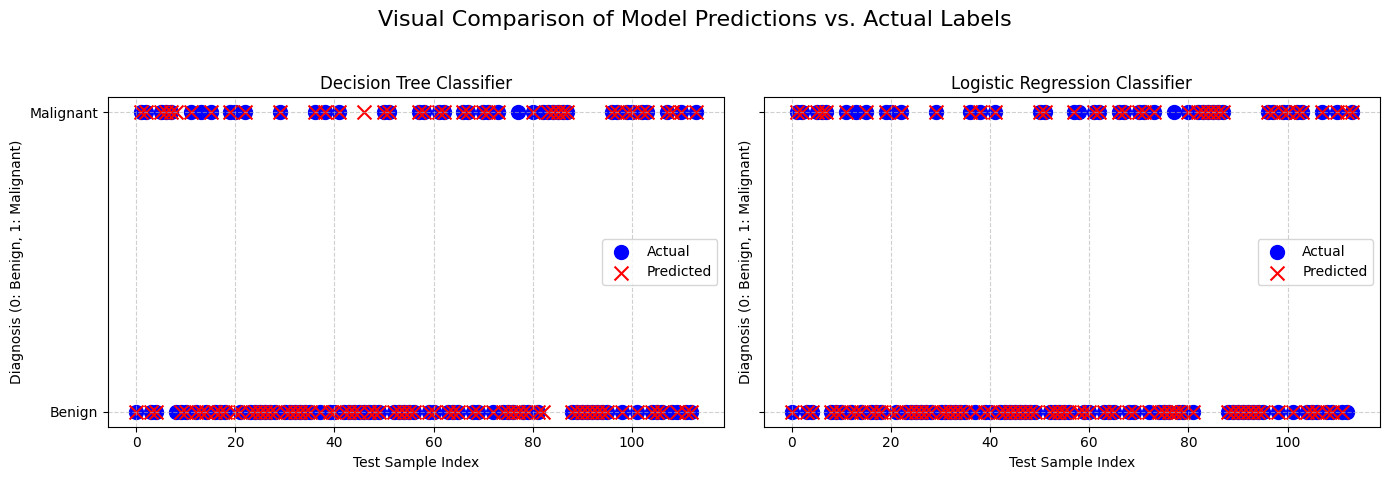

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a DataFrame to hold actual and predicted values for easier plotting
results_df = pd.DataFrame({
    'Actual': y_test_actual,
    'Decision Tree Prediction': y_pred_dt,
    'Logistic Regression Prediction': y_pred_logreg
})
# Reset index to use for plotting individual samples
results_df = results_df.reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('Visual Comparison of Model Predictions vs. Actual Labels', fontsize=16)

# Decision Tree Plot
axes[0].scatter(results_df.index, results_df['Actual'], color='blue', marker='o', s=100, label='Actual')
axes[0].scatter(results_df.index, results_df['Decision Tree Prediction'], color='red', marker='x', s=100, label='Predicted')
axes[0].set_title('Decision Tree Classifier')
axes[0].set_xlabel('Test Sample Index')
axes[0].set_ylabel('Diagnosis (0: Benign, 1: Malignant)')
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['Benign', 'Malignant'])
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Logistic Regression Plot
axes[1].scatter(results_df.index, results_df['Actual'], color='blue', marker='o', s=100, label='Actual')
axes[1].scatter(results_df.index, results_df['Logistic Regression Prediction'], color='red', marker='x', s=100, label='Predicted')
axes[1].set_title('Logistic Regression Classifier')
axes[1].set_xlabel('Test Sample Index')
axes[1].set_ylabel('Diagnosis (0: Benign, 1: Malignant)')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Benign', 'Malignant'])
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

### Visualizando a importância das características na árvore de decisão

Para entender quais características são mais influentes no processo de tomada de decisão da árvore de decisão, vamos visualizar a importância de cada uma delas. Isso nos ajudará a identificar os parâmetros de diagnóstico mais relevantes.

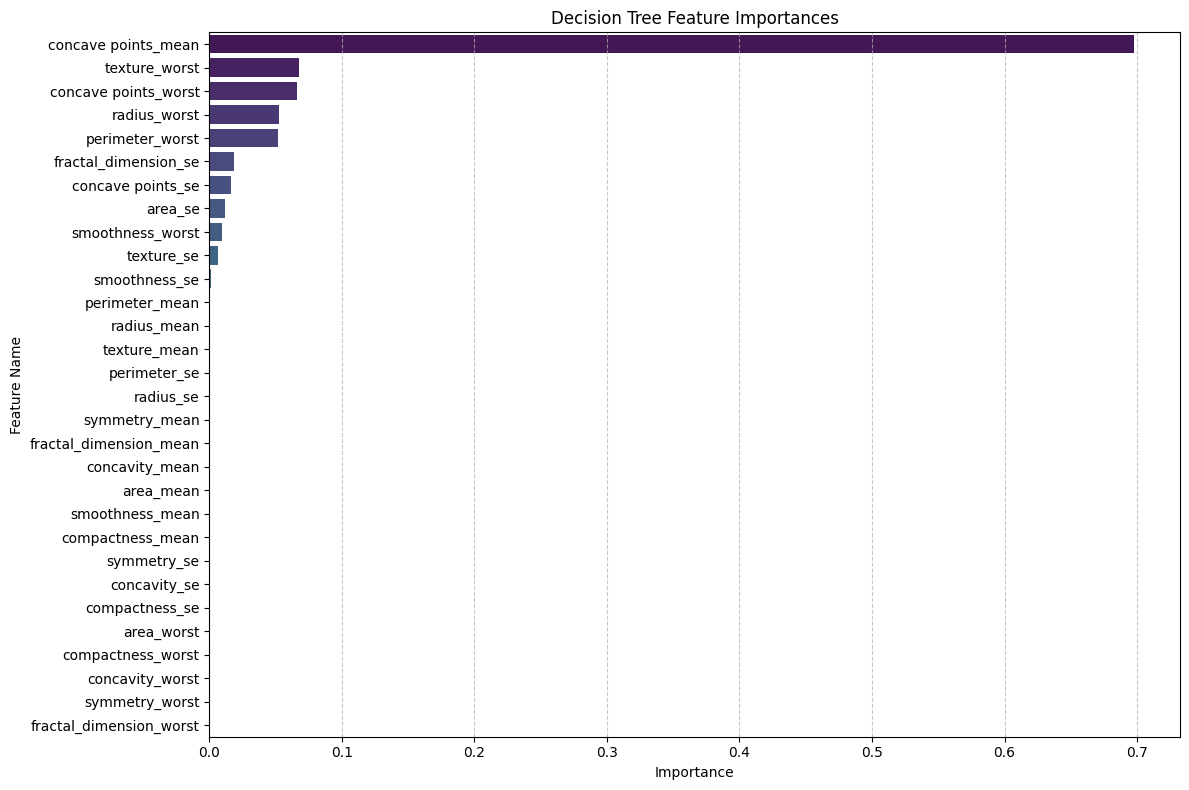

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Ensure the Decision Tree model is fitted to the actual training data before getting importances
# This addresses a potential issue where dt.feature_importances_ might not reflect the latest fit
dt.fit(X_train_actual, y_train_actual)

# Get feature importances from the trained Decision Tree model
importances = dt.feature_importances_

# Get feature names from the X_train_actual DataFrame
feature_names = X_train_actual.columns

# Create a DataFrame for better handling and sorting
feature_importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort the features by importance in descending order
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df, palette='viridis', hue='Feature', legend=False)
plt.title('Decision Tree Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Calcular a Matriz de Confusão

Para avaliar melhor o desempenho dos nossos classificadores, calcularemos e exibiremos a matriz de confusão para os modelos de Árvore de Decisão e Regressão Logística. Isso nos fornecerá informações sobre o número de previsões verdadeiras positivas, verdadeiras negativas, falsas positivas e falsas negativas.

Confusion Matrix for Decision Tree:
[[68  3]
 [ 4 39]]


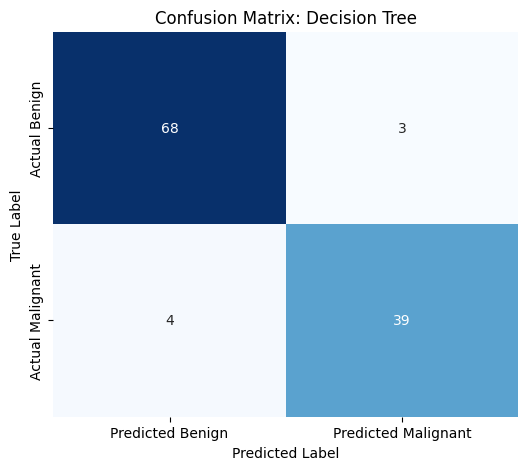


Confusion Matrix for Logistic Regression:
[[70  1]
 [ 4 39]]


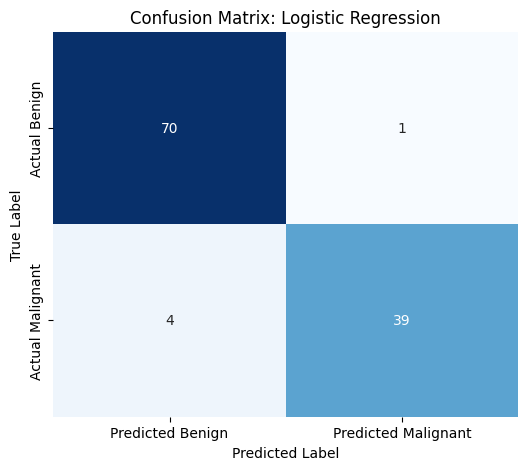

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_test_actual, y_pred_dt)
print("Confusion Matrix for Decision Tree:")
print(cm_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Benign', 'Predicted Malignant'],
            yticklabels=['Actual Benign', 'Actual Malignant'])
plt.title('Confusion Matrix: Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Confusion Matrix for Logistic Regression
cm_logreg = confusion_matrix(y_test_actual, y_pred_logreg)
print("\nConfusion Matrix for Logistic Regression:")
print(cm_logreg)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Benign', 'Predicted Malignant'],
            yticklabels=['Actual Benign', 'Actual Malignant'])
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### **Matriz de Confusão para a Árvore de Decisão:**

```
[[68  3]
 [ 4 39]]
```

-   **68 Verdadeiros Negativos (VN):** O modelo previu corretamente que 68 casos eram **Benignos** e eles realmente eram Benignos. (Canto superior esquerdo)
-   **3 Falsos Positivos (FP):** O modelo previu que 3 casos eram **Malignos**, mas eles eram realmente Benignos. (Canto superior direito - Erro Tipo I)
-   **4 Falsos Negativos (FN):** O modelo previu que 4 casos eram **Benignos**, mas eles eram realmente Malignos. (Canto inferior esquerdo - Erro Tipo II)
-   **39 Verdadeiros Positivos (VP):** O modelo previu corretamente que 39 casos eram **Malignos** e eles realmente eram Malignos. (Canto inferior direito)

---

#### **Matriz de Confusão para a Regressão Logística:**

```
[[70  1]
 [ 4 39]]
```

-   **70 Verdadeiros Negativos (VN):** O modelo previu corretamente que 70 casos eram **Benignos** e eles realmente eram Benignos. (Canto superior esquerdo)
-   **1 Falso Positivo (FP):** O modelo previu que 1 caso era **Maligno**, mas ele era realmente Benigno. (Canto superior direito - Erro Tipo I)
-   **4 Falsos Negativos (FN):** O modelo previu que 4 casos eram **Benignos**, mas eles eram realmente Malignos. (Canto inferior esquerdo - Erro Tipo II)
-   **39 Verdadeiros Positivos (VP):** O modelo previu corretamente que 39 casos eram **Malignos** e eles realmente eram Malignos. (Canto inferior direito)

---

**Comparação:**

*   A **Regressão Logística** teve um desempenho ligeiramente melhor na identificação de casos Benignos, com apenas 1 Falso Positivo (contra 3 da Árvore de Decisão).
*   Ambos os modelos tiveram o mesmo número de Falsos Negativos (4), o que significa que ambos erraram em 4 casos de câncer (Maligno) predizendo que eram Benignos.
*   Ambos os modelos acertaram o mesmo número de Verdadeiros Positivos (39), identificando corretamente os casos Malignos.

### Calculando a acurácia, a precisão e a revocação

Agora, vamos calcular a acurácia, a precisão e a revocação para os modelos de Árvore de Decisão e Regressão Logística. Essas métricas fornecem uma avaliação mais abrangente do desempenho do modelo, especialmente em conjuntos de dados desbalanceados.

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# --- Decision Tree Metrics ---
acc_dt = accuracy_score(y_test_actual, y_pred_dt)
precision_dt = precision_score(y_test_actual, y_pred_dt)
recall_dt = recall_score(y_test_actual, y_pred_dt)

print("Decision Tree Metrics:")
print(f"  Accuracy: {acc_dt:.4f}")
print(f"  Precision: {precision_dt:.4f}")
print(f"  Recall: {recall_dt:.4f}")

# --- Logistic Regression Metrics ---
acc_logreg = accuracy_score(y_test_actual, y_pred_logreg)
precision_logreg = precision_score(y_test_actual, y_pred_logreg)
recall_logreg = recall_score(y_test_actual, y_pred_logreg)

print("\nLogistic Regression Metrics:")
print(f"  Accuracy: {acc_logreg:.4f}")
print(f"  Precision: {precision_logreg:.4f}")
print(f"  Recall: {recall_logreg:.4f}")

Decision Tree Metrics:
  Accuracy: 0.9386
  Precision: 0.9286
  Recall: 0.9070

Logistic Regression Metrics:
  Accuracy: 0.9561
  Precision: 0.9750
  Recall: 0.9070


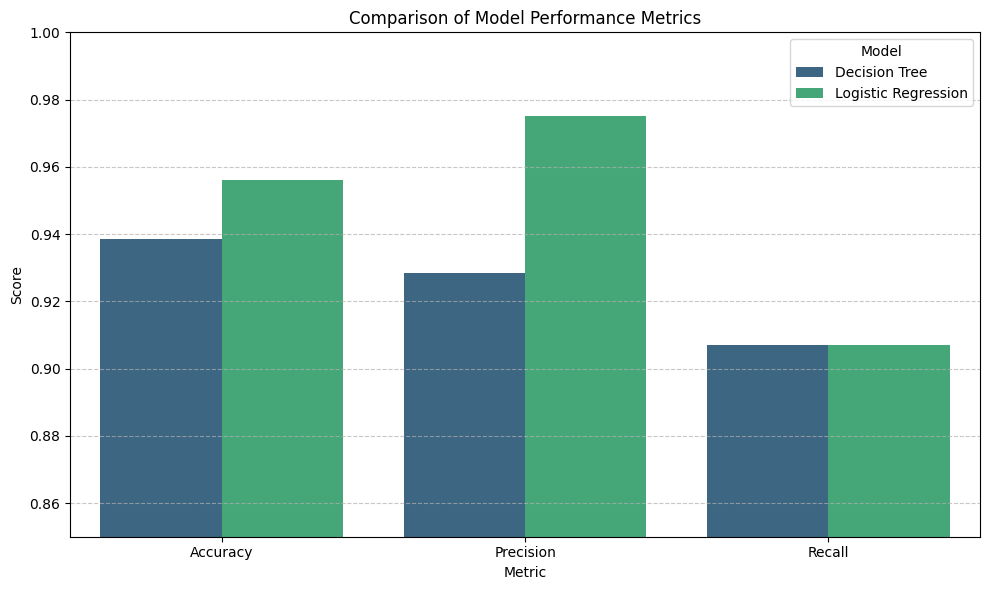

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame to hold the metrics for easier plotting
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall'],
    'Decision Tree': [acc_dt, precision_dt, recall_dt],
    'Logistic Regression': [acc_logreg, precision_logreg, recall_logreg]
}
metrics_df = pd.DataFrame(metrics_data)

# Melt the DataFrame to long format for seaborn barplot
metrics_df_melted = metrics_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_df_melted, palette='viridis')
plt.title('Comparison of Model Performance Metrics')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0.85, 1.0) # Set a relevant y-axis limit for better comparison
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

### Plotar as Curvas ROC

Para avaliar melhor o desempenho dos nossos modelos, especialmente considerando a relação entre a taxa de verdadeiros positivos (sensibilidade) e a taxa de falsos positivos (1 - especificidade), vamos plotar a curva ROC (Receiver Operating Characteristic) para os modelos de Árvore de Decisão e Regressão Logística. Também calcularemos a Área Sob a Curva (AUC), que resume a capacidade do modelo de distinguir entre as classes.

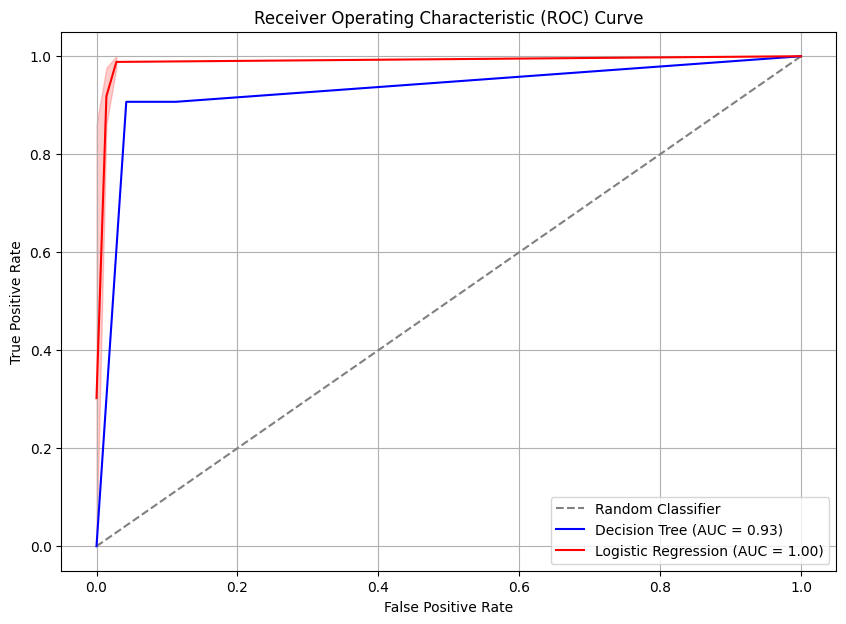

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Decision Tree ROC Curve and AUC ---
# Get predicted probabilities for the positive class (malignant = 1)
y_pred_proba_dt = dt.predict_proba(X_test_actual)[:, 1]
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test_actual, y_pred_proba_dt)
auc_dt = roc_auc_score(y_test_actual, y_pred_proba_dt)

# --- Logistic Regression ROC Curve and AUC ---
y_pred_proba_logreg = logreg.predict_proba(X_test_actual)[:, 1]
fpr_logreg, tpr_logreg, thresholds_logreg = roc_curve(y_test_actual, y_pred_proba_logreg)
auc_logreg = roc_auc_score(y_test_actual, y_pred_proba_logreg)

# Plotting the ROC curves
plt.figure(figsize=(10, 7))
sns.lineplot(x=[0, 1], y=[0, 1], linestyle='--', label='Random Classifier', color='gray')
sns.lineplot(x=fpr_dt, y=tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})', color='blue')
sns.lineplot(x=fpr_logreg, y=tpr_logreg, label=f'Logistic Regression (AUC = {auc_logreg:.2f})', color='red')

plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

### Salvar modelos treinados

Para garantir que os modelos treinados possam ser reutilizados sem a necessidade de novo treinamento, vou salvá-los em disco usando a biblioteca `joblib`. Essa é uma prática comum para persistir modelos de aprendizado de máquina.

In [39]:
import joblib

# Save the Decision Tree model
joblib.dump(dt, 'decision_tree_model.pkl')
print("Decision Tree model saved as 'decision_tree_model.pkl'")

# Save the Logistic Regression model
joblib.dump(logreg, 'logistic_regression_model.pkl')
print("Logistic Regression model saved as 'logistic_regression_model.pkl'")

Decision Tree model saved as 'decision_tree_model.pkl'
Logistic Regression model saved as 'logistic_regression_model.pkl'


### Relatório de Classificação

Para obter uma análise mais detalhada do desempenho do modelo, além da acurácia, precisão e recall, usamos o `classification_report`. Este relatório fornece essas métricas por classe, juntamente com a pontuação F1 e o suporte (número de ocorrências reais da classe no conjunto de dados especificado).

In [40]:
from sklearn.metrics import classification_report

# --- Decision Tree Classification Report ---
print("Classification Report for Decision Tree:")
print(classification_report(y_test_actual, y_pred_dt))

# --- Logistic Regression Classification Report ---
print("\nClassification Report for Logistic Regression:")
print(classification_report(y_test_actual, y_pred_logreg))

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        71
           1       0.93      0.91      0.92        43

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### Visualizar a Distribuição da Variável Alvo

É importante entender a distribuição da nossa variável alvo ('diagnóstico') para verificar o desequilíbrio entre as classes. Um desequilíbrio entre as classes pode afetar o desempenho do modelo, especialmente para algoritmos que pressupõem classes balanceadas. Vamos visualizar a quantidade de casos 'Malignos' (M) e 'Benignos' (B) no conjunto de dados original.

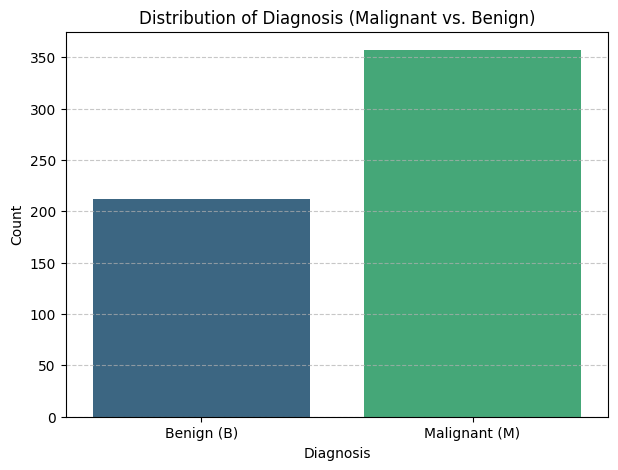

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a count plot for the 'diagnosis' column from the original df
plt.figure(figsize=(7, 5))
sns.countplot(x='diagnosis', data=df, palette='viridis', hue='diagnosis', legend=False)
plt.title('Distribution of Diagnosis (Malignant vs. Benign)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Benign (B)', 'Malignant (M)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Importância das Atributos na Regressão Logística

Ao contrário de modelos baseados em árvores (como Árvores de Decisão) que fornecem diretamente a importância dos atributos, os modelos de Regressão Logística utilizam a magnitude de seus coeficientes para indicar a importância dos atributos. Um valor absoluto maior para o coeficiente sugere uma influência mais forte no resultado previsto.

No entanto, é crucial realizar o **escalonamento dos atributos** (por exemplo, Padronização) antes de interpretar os coeficientes da Regressão Logística como indicadores de importância. Sem o escalonamento, os atributos com escalas naturais maiores teriam coeficientes menores, tornando a comparação direta enganosa. Como nossos dados originais (`X_train_actual`) não foram escalonados antes do treinamento do modelo `logreg` inicial, iremos escaloná-los agora e treinar um novo modelo de Regressão Logística para obter coeficientes comparáveis.

In [42]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train_actual)
X_test_scaled = scaler.transform(X_test_actual)

print("Data scaled successfully using StandardScaler.")

Data scaled successfully using StandardScaler.


In [43]:
from sklearn.linear_model import LogisticRegression

# Instantiate a new Logistic Regression model with scaled data
logreg_scaled = LogisticRegression(random_state=1, max_iter=1000) # Increased max_iter to prevent ConvergenceWarning

# Fit logreg_scaled to the scaled training set
logreg_scaled.fit(X_train_scaled, y_train_actual)

print("Logistic Regression model retrained successfully on scaled data.")

Logistic Regression model retrained successfully on scaled data.


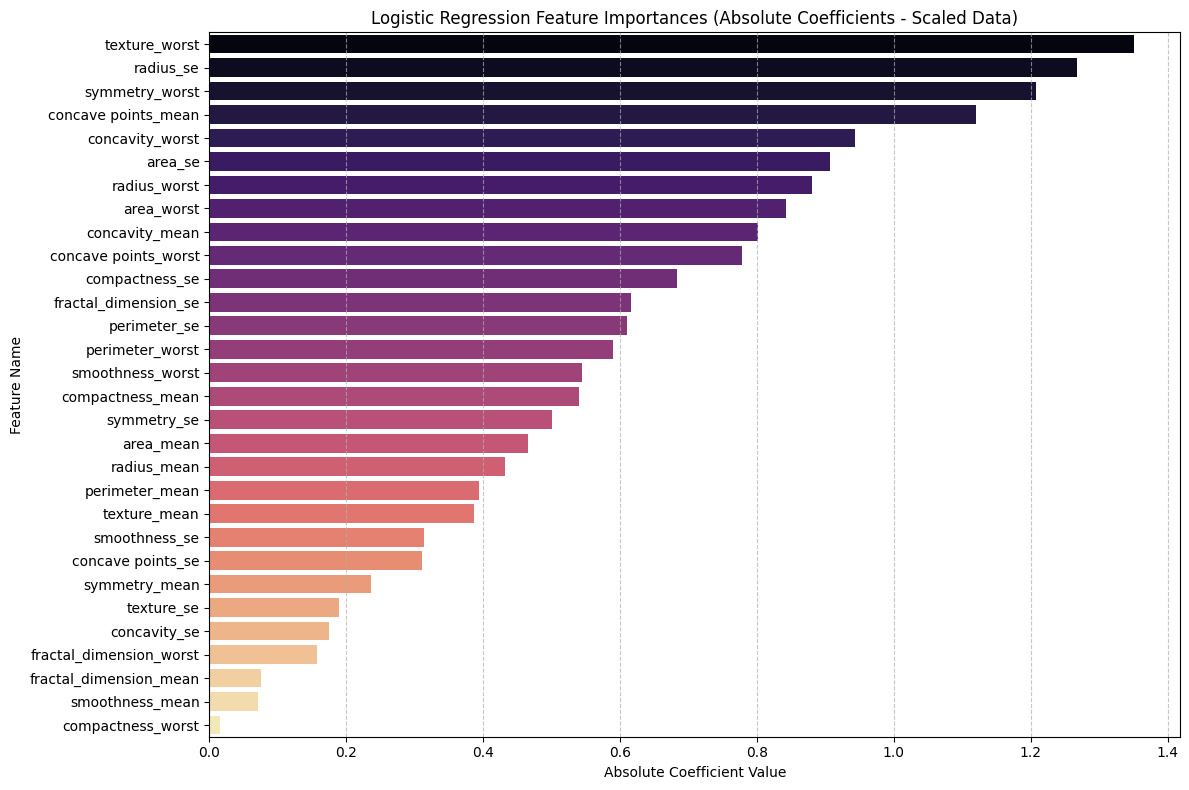

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Get coefficients from the scaled Logistic Regression model
coefficients = logreg_scaled.coef_[0]

# Create a DataFrame for better handling and sorting
# Using absolute values for importance comparison
logistic_feature_importances_df = pd.DataFrame({
    'Feature': X_train_actual.columns,
    'Importance': np.abs(coefficients) # Use absolute value for importance
})

# Sort the features by importance in descending order
logistic_feature_importances_df = logistic_feature_importances_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances for Logistic Regression
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=logistic_feature_importances_df, palette='magma', hue='Feature', legend=False)
plt.title('Logistic Regression Feature Importances (Absolute Coefficients - Scaled Data)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparando a Importância das Características

Agora que visualizamos a importância das características na Árvore de Decisão e os coeficientes absolutos (escalonados) da Regressão Logística, podemos comparar quais características cada modelo considerou mais influentes:

* **Árvore de Decisão:** Normalmente destaca algumas características dominantes que levam a divisões claras nos dados. O gráfico da célula `a2e7a239` mostra suas principais características.

* **Regressão Logística:** Atribui importância com base na força da correlação de uma característica (quando escalonada) com o logaritmo da razão de chances (log-odds) da variável alvo. Características com valores de coeficiente absoluto maiores têm um impacto maior.

Ao examinar ambos os gráficos, você pode observar se há sobreposição nas características mais importantes identificadas por esses modelos fundamentalmente diferentes. Um alto grau de sobreposição sugere que essas características são preditores robustos em diferentes abordagens de modelagem.

### Conclusão do Modelo

Com base na análise realizada, segue um resumo do desempenho do modelo no conjunto de teste de 114 amostras:

* **Classificador de Árvore de Decisão:**

* Acurácia: 0,9386

* Precisão: 0,9286

* Revocação: 0,9070

* **Regressão Logística:**

* Acurácia: 0,9561

* Precisão: 0,9750

* Revocação: 0,9070

Ambos os modelos demonstram um desempenho sólido na classificação de casos malignos e benignos. A Regressão Logística apresenta acurácia e precisão ligeiramente superiores neste conjunto de teste específico.



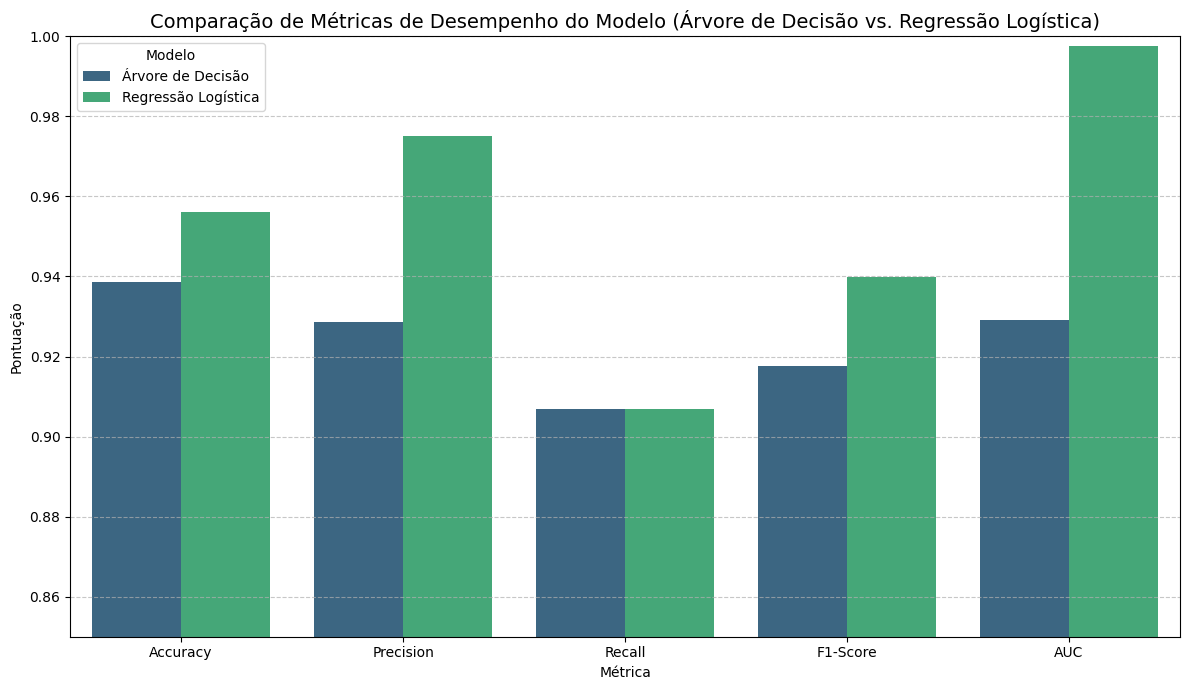

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Adding F1-score and AUC to the metrics_data for a comprehensive comparison
metrics_data_final = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    'Árvore de Decisão': [acc_dt, precision_dt, recall_dt, f1_dt, auc_dt],
    'Regressão Logística': [acc_logreg, precision_logreg, recall_logreg, f1_logreg, auc_logreg]
}
metrics_df_final = pd.DataFrame(metrics_data_final)

# Melt the DataFrame to long format for seaborn barplot
metrics_df_melted_final = metrics_df_final.melt(id_vars='Metric', var_name='Modelo', value_name='Pontuação')

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Pontuação', hue='Modelo', data=metrics_df_melted_final, palette='viridis')
plt.title('Comparação de Métricas de Desempenho do Modelo (Árvore de Decisão vs. Regressão Logística)', fontsize=14)
plt.xlabel('Métrica')
plt.ylabel('Pontuação')
plt.ylim(0.85, 1.0) # Set a relevant y-axis limit for better comparison
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Modelo')
plt.tight_layout()
plt.show()